<a href="https://colab.research.google.com/github/saverin0/Change-Detection-Using-Dinov3/blob/main/00_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SpaceNet-7 Temporal Change Detection with DINOv3
## Part 0: Exploring the SpaceNet-7 Dataset

### What this notebook does
A look at the raw data before any processing. It reads only the dataset itself, so it runs **before Part 1** and needs nothing from the cache. Every later design choice in Parts 1–4 comes from something visible here.

| Step | What it shows |
|---|---|
| 4 | **Inventory:** locations, months, images, labels, image size and bands |
| 5 | **Month coverage:** which months each location has, and where months are missing |
| 6 | **One location up close:** images over time, and footprints coloured by when a building first and last appears |
| 7 | **Building counts over time** for every location, and which locations change the most |
| 8 | **Cloud masks:** how much of each month is masked, and how that distorts building counts |
| 9 | **Data quality summary** saved to Drive |

### The dataset in one paragraph
SpaceNet-7 (the *Multi-Temporal Urban Development* dataset) covers **60 locations** around the world, each a ~4 km × 4 km tile at ~4 m per pixel, imaged **once a month for about two years** (2017-07 to 2020-01) by Planet's satellites. Every month comes with **building footprints** whose `Id`s are matched across months, so the same building keeps the same `Id` from the month it appears to the month it disappears. Cloudy parts of a month are blacked out in `images_masked/`, and buildings under those areas are left out of that month's labels.

### Folder layout of one location
```
L15-<tile id>/
├── images/             one GeoTIFF per month, unmasked
├── images_masked/      same months, clouds blacked out          <- used by Parts 1-2
├── labels/             footprints + UDM (cloud) polygons per month
├── labels_match/       footprints with Ids matched across months  <- used by Part 1
├── labels_match_pix/   the same in pixel coordinates
└── UDM_masks/          cloud-mask rasters, only for cloudy months (missing in 16 locations)
```

## Step 1: Mount Google Drive

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Import libraries

GeoPandas, Shapely, and Matplotlib ship with Colab. **rasterio** (reading GeoTIFFs) is installed if missing.

In [2]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("rasterio") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rasterio"])

import json
import re
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from tqdm.auto import tqdm

## Step 3: Configuration

`DATA_ROOT` is the folder with the 60 `L15-*` location folders, the same path Part 1 uses. Figures and the summary table go to `spacenet7_cache/exploration/` on Drive.

Set `MAX_LOCATIONS` to a small number for a quick look; `None` uses all 60.

In [3]:
DATA_ROOT = Path("/content/drive/MyDrive/datasets/spacenet7/SN7_buildings_train/train")
OUTPUT_DIR = Path("/content/drive/MyDrive/datasets/spacenet7_cache/exploration")
MAX_LOCATIONS = None

if not DATA_ROOT.is_dir():
    raise FileNotFoundError(f"{DATA_ROOT} not found. Check the Drive path.")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

locations = sorted(p for p in DATA_ROOT.iterdir() if p.is_dir() and p.name.startswith("L15-"))
if MAX_LOCATIONS:
    locations = locations[:MAX_LOCATIONS]
print(f"{len(locations)} locations under {DATA_ROOT}")

60 locations under /content/drive/MyDrive/datasets/spacenet7/SN7_buildings_train/train


## Step 4: Inventory

For every location this lists its subfolders and counts the monthly images and label files. It then opens one GeoTIFF to show the image size, bands, and data type. What to expect:
- 60 locations, **1,423 months in total** (18–26 per location)
- one image in `images_masked/` for every label file in `labels_match/` (Part 2 relies on this)
- 4-band `uint8` images, 1024×1024 or 1023×1024 pixels (RGB + an alpha band)
- `UDM_masks/` present only where clouds occurred

Reading all the GeoJSON files with `json` (not GeoPandas) keeps this fast: only feature counts and `Id`s are needed here, not geometries.

In [4]:
MONTH_RE = re.compile(r"global_monthly_(\d{4}_\d{2})")


def month_of(path):
    match = MONTH_RE.search(path.name)
    return match.group(1) if match else None


def read_month_ids(label_file):
    with open(label_file) as f:
        features = json.load(f).get("features", [])
    return month_of(label_file), [feat["properties"].get("Id") for feat in features]


def inventory(location):
    subfolders = sorted(p.name for p in location.iterdir() if p.is_dir())
    images = {month_of(p): p for p in (location / "images_masked").glob("*.tif")}
    label_files = sorted((location / "labels_match").glob("*.geojson"))
    months = {}
    for month, ids in map(read_month_ids, label_files):
        months[month] = ids
    return {"loc_id": location.name, "subfolders": subfolders, "images": images, "months": months,
            "udm_months": {month_of(p) for p in (location / "UDM_masks").glob("*.tif")}}


with ThreadPoolExecutor(max_workers=16) as pool:
    info = dict(zip([l.name for l in locations], tqdm(pool.map(inventory, locations), total=len(locations), desc="Reading labels")))

rows = []
for loc_id, d in info.items():
    months = sorted(d["months"])
    rows.append({"location": loc_id, "months": len(months), "first": months[0], "last": months[-1],
                 "images": len(d["images"]), "image_label_mismatch": len(set(d["images"]) ^ set(months)),
                 "buildings_first": len(d["months"][months[0]]), "buildings_last": len(d["months"][months[-1]]),
                 "unique_ids": len({i for ids in d["months"].values() for i in ids}),
                 "cloudy_months (UDM)": len(d["udm_months"]), "has_UDM_folder": "UDM_masks" in d["subfolders"]})
inventory_df = pd.DataFrame(rows).set_index("location")

subfolder_counts = Counter(name for d in info.values() for name in d["subfolders"])
print("Subfolders (in how many locations):", dict(subfolder_counts))
print(f"Total months: {inventory_df['months'].sum()} | per location: {inventory_df['months'].min()}-{inventory_df['months'].max()}")
print(f"Image/label month mismatches: {inventory_df['image_label_mismatch'].sum()}")

sample_image = next(iter(info[locations[0].name]["images"].values()))
with rasterio.open(sample_image) as src:
    print(f"Sample GeoTIFF: {src.width}x{src.height} px, {src.count} bands, {src.dtypes[0]}, CRS {src.crs}")
    print(f"   pixel size: {abs(src.transform.a):.2f} x {abs(src.transform.e):.2f} map units")

inventory_df.head(10)

Reading labels:   0%|          | 0/60 [00:00<?, ?it/s]

Subfolders (in how many locations): {'images': 60, 'images_masked': 60, 'labels': 60, 'labels_match': 60, 'labels_match_pix': 60, 'UDM_masks': 44}
Total months: 1423 | per location: 18-26
Image/label month mismatches: 0
Sample GeoTIFF: 1024x1023 px, 4 bands, uint8, CRS EPSG:3857
   pixel size: 4.78 x 4.78 map units


,months,first,last,images,image_label_mismatch,buildings_first,buildings_last,unique_ids,cloudy_months (UDM),has_UDM_folder
location,,,,,,,,,,
L15-0331E-1257N_1327_3160_13,25,2018_01,2020_01,25,0,1940,2108,2156,0,False
L15-0357E-1223N_1429_3296_13,25,2018_01,2020_01,25,0,4634,4910,4935,0,False
L15-0358E-1220N_1433_3310_13,24,2018_02,2020_01,24,0,3970,4797,4807,2,True
L15-0361E-1300N_1446_2989_13,24,2018_01,2020_01,24,0,3860,4742,4755,1,True
L15-0368E-1245N_1474_3210_13,24,2018_01,2020_01,24,0,9720,10086,10099,0,False
L15-0387E-1276N_1549_3087_13,22,2018_01,2019_12,22,0,1371,1691,1878,7,True
L15-0434E-1218N_1736_3318_13,25,2018_01,2020_01,25,0,22,54,114,0,False
L15-0457E-1135N_1831_3648_13,24,2018_01,2019_12,24,0,13469,13962,14034,6,True
L15-0487E-1246N_1950_3207_13,25,2018_01,2020_01,25,0,681,838,859,5,True


## Step 5: Month coverage

Each row is a location, each column a calendar month; a filled cell means that month has an image and labels. Gaps are real: 34 locations skip at least one month, and the time between two consecutive frames can be 1 to 4 months. Part 3 therefore gives the model the **calendar gap** between frames, not just their order.

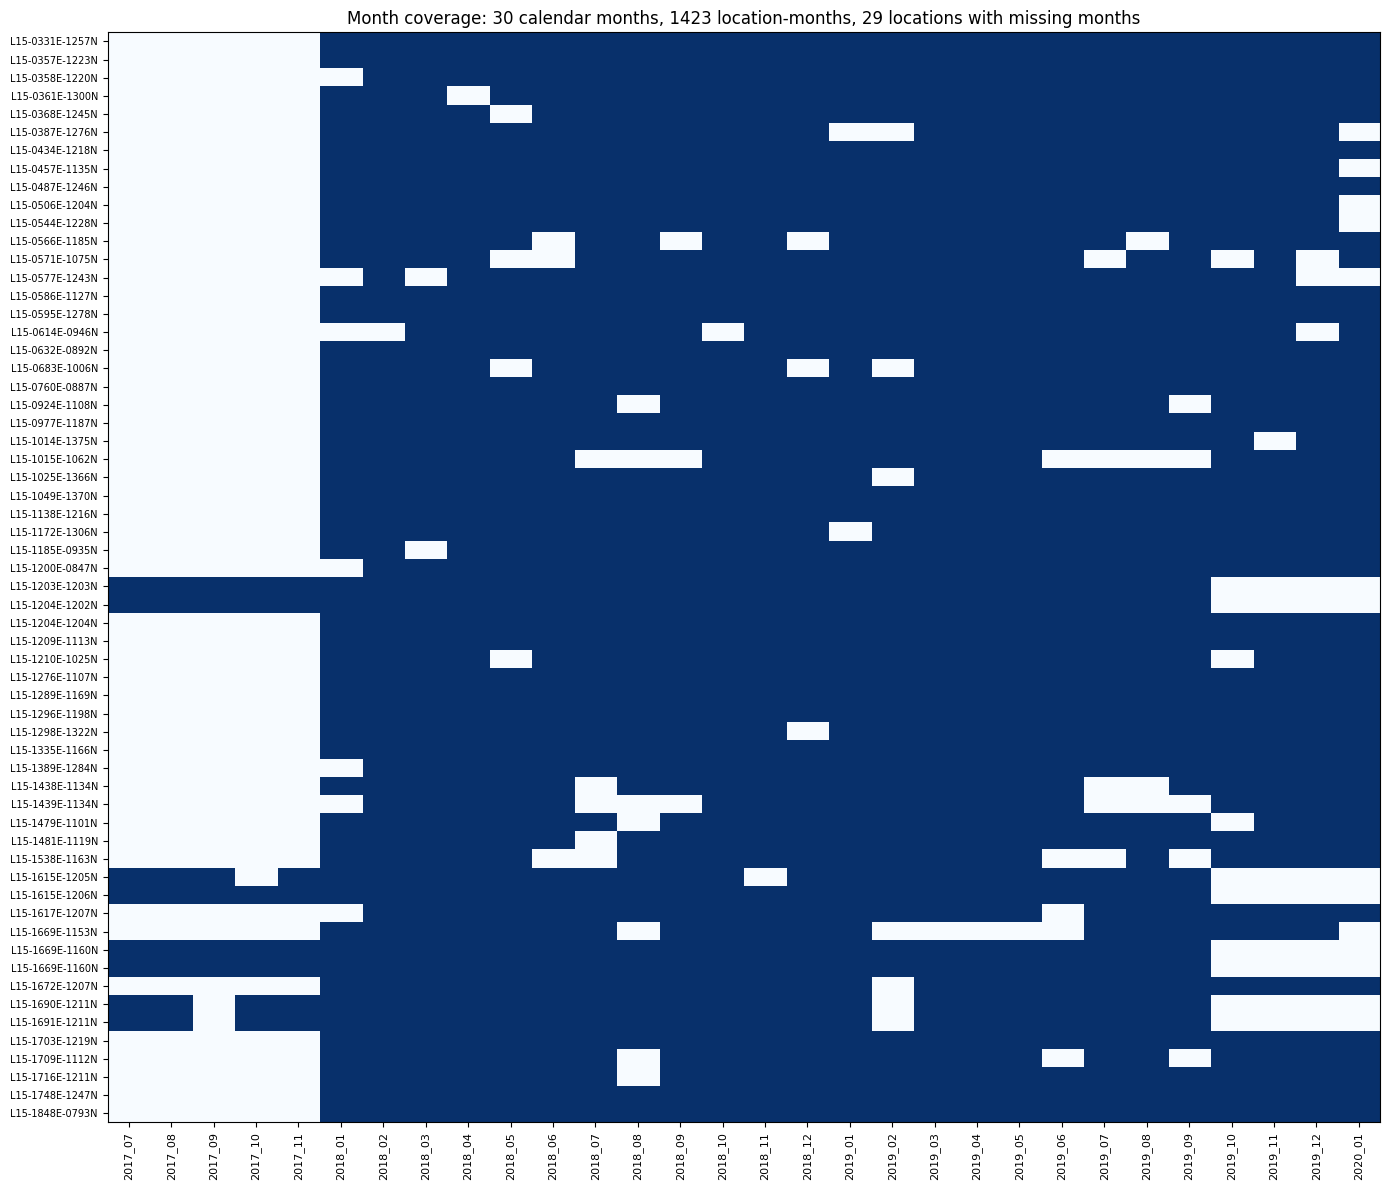

In [5]:
all_months = sorted({m for d in info.values() for m in d["months"]})
coverage = pd.DataFrame(0, index=list(info), columns=all_months)
for loc_id, d in info.items():
    coverage.loc[loc_id, list(d["months"])] = 1

gaps = 0
for loc_id, d in info.items():
    present = sorted(d["months"])
    idx = [all_months.index(m) for m in present]
    gaps += int(idx[-1] - idx[0] + 1 != len(idx))

fig, ax = plt.subplots(figsize=(14, 12))
ax.imshow(coverage.values, cmap="Blues", aspect="auto", interpolation="nearest")
ax.set_xticks(range(len(all_months)))
ax.set_xticklabels(all_months, rotation=90, fontsize=8)
ax.set_yticks(range(len(coverage)))
ax.set_yticklabels([i[:15] for i in coverage.index], fontsize=7)
ax.set_title(f"Month coverage: {len(all_months)} calendar months, {coverage.values.sum()} location-months, "
             f"{gaps} locations with missing months")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "month_coverage.png", dpi=150)
plt.show()

## Step 6: One location up close

For one location (`LOC_ID`, by default the first one):
- **Top row:** the masked image for six months spread across the timeline. Black areas are cloud masks.
- **Bottom left:** the last month's footprints coloured by their history, computed straight from the `Id`s:
  - **green** present from the first month to the last (persisting)
  - **blue** first seen after the first month (new)
  - **red** buildings from the first month that are gone by the last (demolished, drawn with the first month's footprints)
- **Bottom right:** the number of buildings in each month.

Building `Id`s are matched across months, which is what makes this per-building history possible.

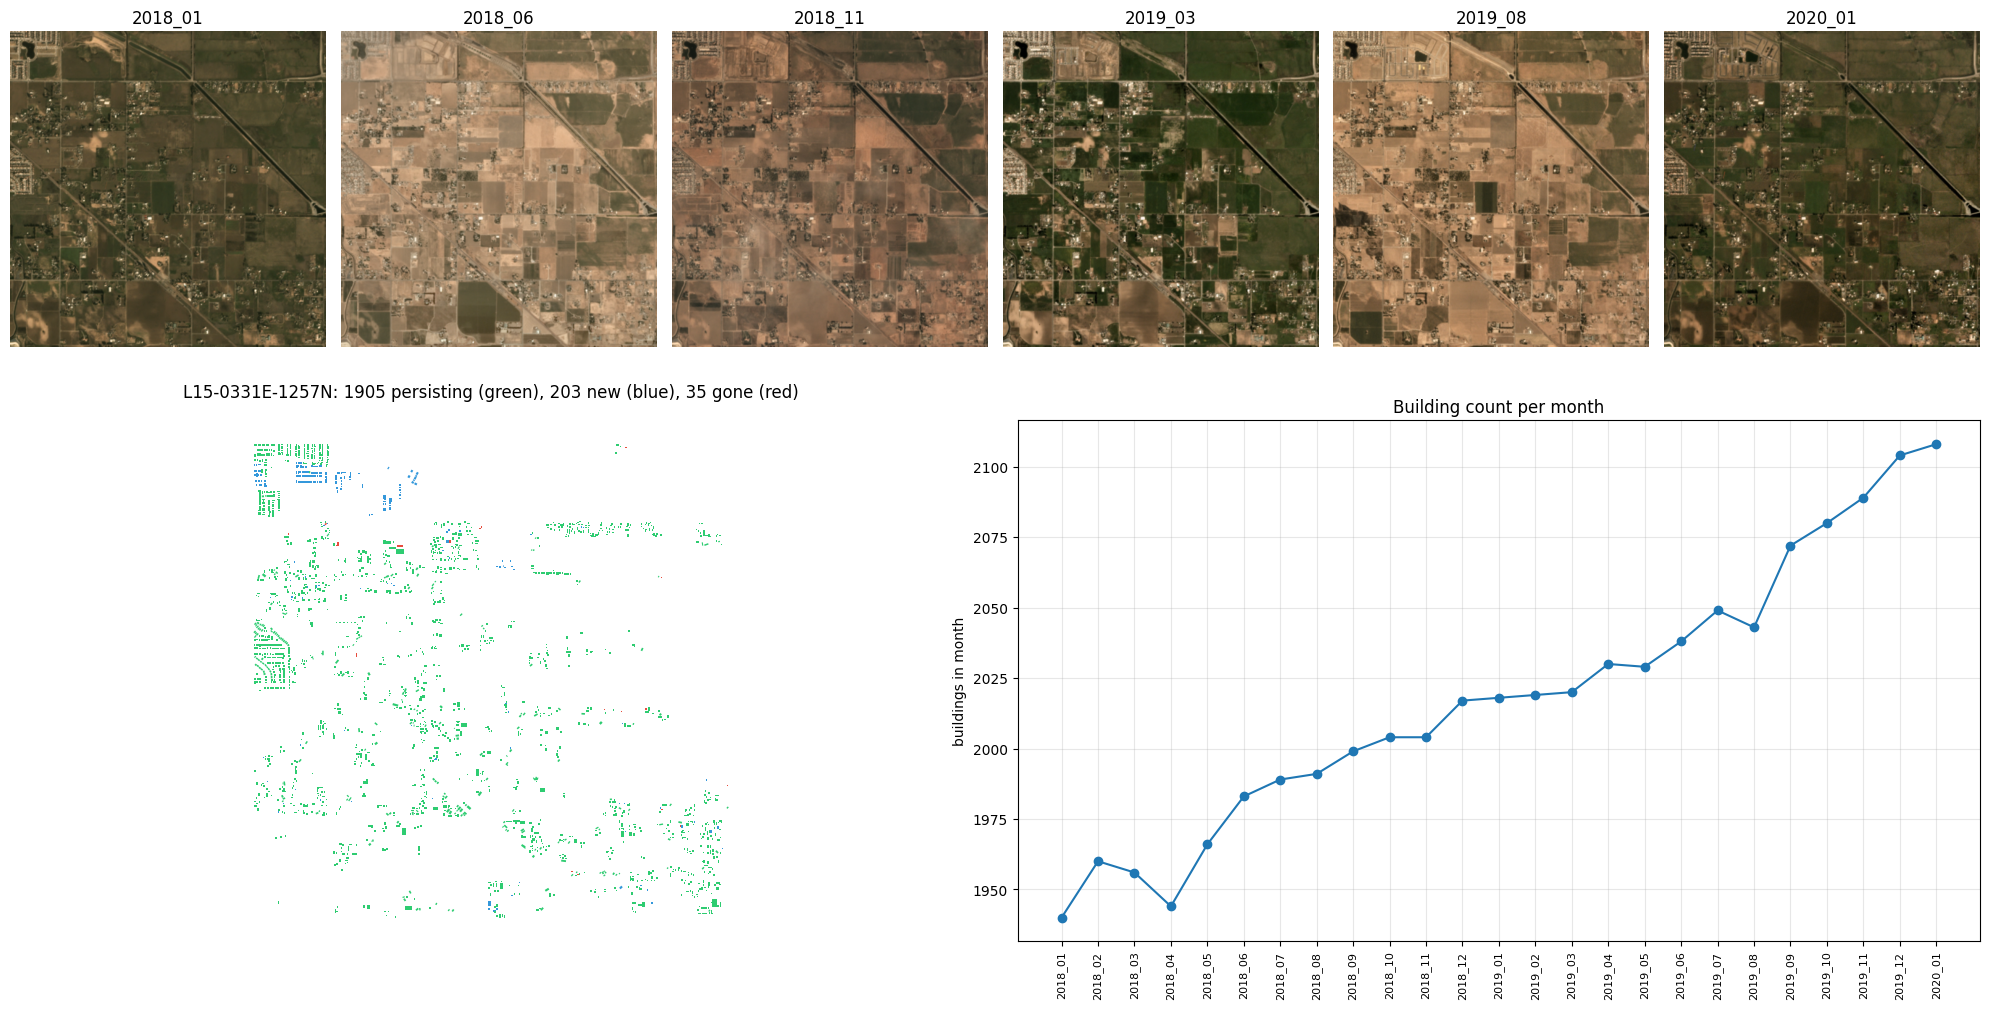

In [6]:
LOC_ID = locations[0].name
d = info[LOC_ID]
months = sorted(d["months"])
picks = np.linspace(0, len(months) - 1, 6).round().astype(int)


def read_rgb(path, size=512):
    with rasterio.open(path) as src:
        img = src.read([1, 2, 3], out_shape=(3, size, size), resampling=Resampling.bilinear)
    return np.transpose(img, (1, 2, 0))


def read_footprints(location, month):
    path = next((location / "labels_match").glob(f"global_monthly_{month}_*.geojson"))
    gdf = gpd.read_file(path)
    if "Id" not in gdf.columns:
        gdf["Id"] = range(len(gdf))
    return gdf[gdf.geometry.notna() & gdf.geometry.is_valid]


first_ids, last_ids = set(d["months"][months[0]]), set(d["months"][months[-1]])
location = DATA_ROOT / LOC_ID
first_gdf, last_gdf = read_footprints(location, months[0]), read_footprints(location, months[-1])

fig = plt.figure(figsize=(20, 11))
for i, t in enumerate(picks):
    ax = fig.add_subplot(2, 6, i + 1)
    ax.imshow(read_rgb(d["images"][months[t]]))
    ax.set_title(months[t])
    ax.axis("off")

ax = fig.add_subplot(2, 2, 3)
last_gdf[last_gdf["Id"].isin(first_ids)].plot(ax=ax, color="#2ecc71", linewidth=0)
last_gdf[~last_gdf["Id"].isin(first_ids)].plot(ax=ax, color="#3498db", linewidth=0)
first_gdf[~first_gdf["Id"].isin(last_ids)].plot(ax=ax, color="#e74c3c", linewidth=0)
ax.set_title(f"{LOC_ID[:15]}: {len(first_ids & last_ids)} persisting (green), {len(last_ids - first_ids)} new (blue), "
             f"{len(first_ids - last_ids)} gone (red)")
ax.set_aspect("equal")
ax.axis("off")

ax = fig.add_subplot(2, 2, 4)
ax.plot(range(len(months)), [len(d["months"][m]) for m in months], marker="o")
ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=90, fontsize=8)
ax.set_ylabel("buildings in month")
ax.set_title("Building count per month")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"location_{LOC_ID}.png", dpi=150)
plt.show()

## Step 7: Building counts over time, all locations

Left: every location's building count by month, normalised to its first month, with the median in black. Right: the locations ranked by growth (last month ÷ first month).

Two things to notice:
- Most locations grow steadily, a few by 50% or more over two years: these are the places with real construction.
- Some curves **dip sharply for one month and recover**. A city doesn't lose a third of its buildings and get them back a month later; those dips are months where clouds hid part of the tile and its buildings were left out of the labels. Step 8 measures this.

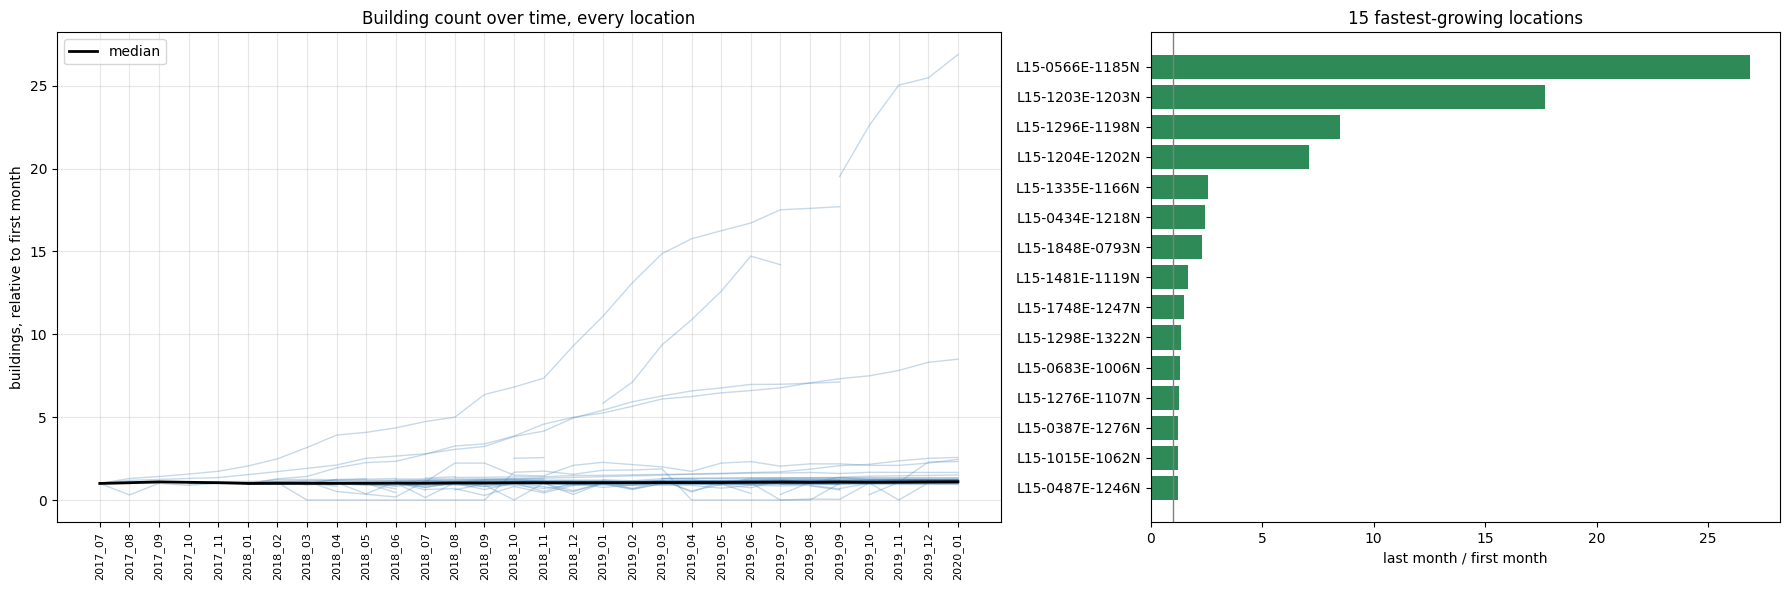

Buildings in first months: 283,206 | in last months: 307,405 (+9%)
Locations with a month-to-month drop of more than 20%: 21


In [7]:
counts = pd.DataFrame({loc_id: {m: len(ids) for m, ids in d["months"].items()} for loc_id, d in info.items()})
counts = counts.reindex(all_months)
normalised = counts / counts.apply(lambda s: s.dropna().iloc[0])

growth = pd.DataFrame({
    "first": counts.apply(lambda s: s.dropna().iloc[0]), "last": counts.apply(lambda s: s.dropna().iloc[-1]),
    "growth": counts.apply(lambda s: s.dropna().iloc[-1] / max(s.dropna().iloc[0], 1)),
    "largest_month_drop": counts.apply(lambda s: (1 - s.dropna() / s.dropna().cummax()).max()),
}).sort_values("growth", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [3, 2]})
for loc_id in normalised:
    axes[0].plot(range(len(all_months)), normalised[loc_id].values, color="steelblue", alpha=0.3, linewidth=1)
axes[0].plot(range(len(all_months)), normalised.median(axis=1).values, color="black", linewidth=2, label="median")
axes[0].set_xticks(range(len(all_months)))
axes[0].set_xticklabels(all_months, rotation=90, fontsize=8)
axes[0].set_ylabel("buildings, relative to first month")
axes[0].set_title("Building count over time, every location")
axes[0].legend()
axes[0].grid(alpha=0.3)

top = growth.head(15)
axes[1].barh([i[:15] for i in top.index][::-1], top["growth"].values[::-1], color="seagreen")
axes[1].axvline(1, color="grey", linewidth=1)
axes[1].set_xlabel("last month / first month")
axes[1].set_title("15 fastest-growing locations")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "building_counts.png", dpi=150)
plt.show()

print(f"Buildings in first months: {int(growth['first'].sum()):,} | in last months: {int(growth['last'].sum()):,} "
      f"(+{100 * (growth['last'].sum() / growth['first'].sum() - 1):.0f}%)")
print(f"Locations with a month-to-month drop of more than 20%: {(growth['largest_month_drop'] > 0.2).sum()}")

## Step 8: Cloud masks and the building-count dips

`UDM_masks/` holds a raster per **cloudy** month (0 = clear, 255 = masked); months with no file are clear. For every location-month this computes the **masked fraction of the tile**, then plots it as a heatmap and against the building-count drop of that month.

The two are tightly linked: a month that is 30% masked loses roughly 30% of its buildings from the labels. That's the artifact that made **88% of the raw change labels** in Part 1 fake, and why Parts 3 and 4 ignore masked pixels.

UDM masks:   0%|          | 0/1423 [00:00<?, ?it/s]

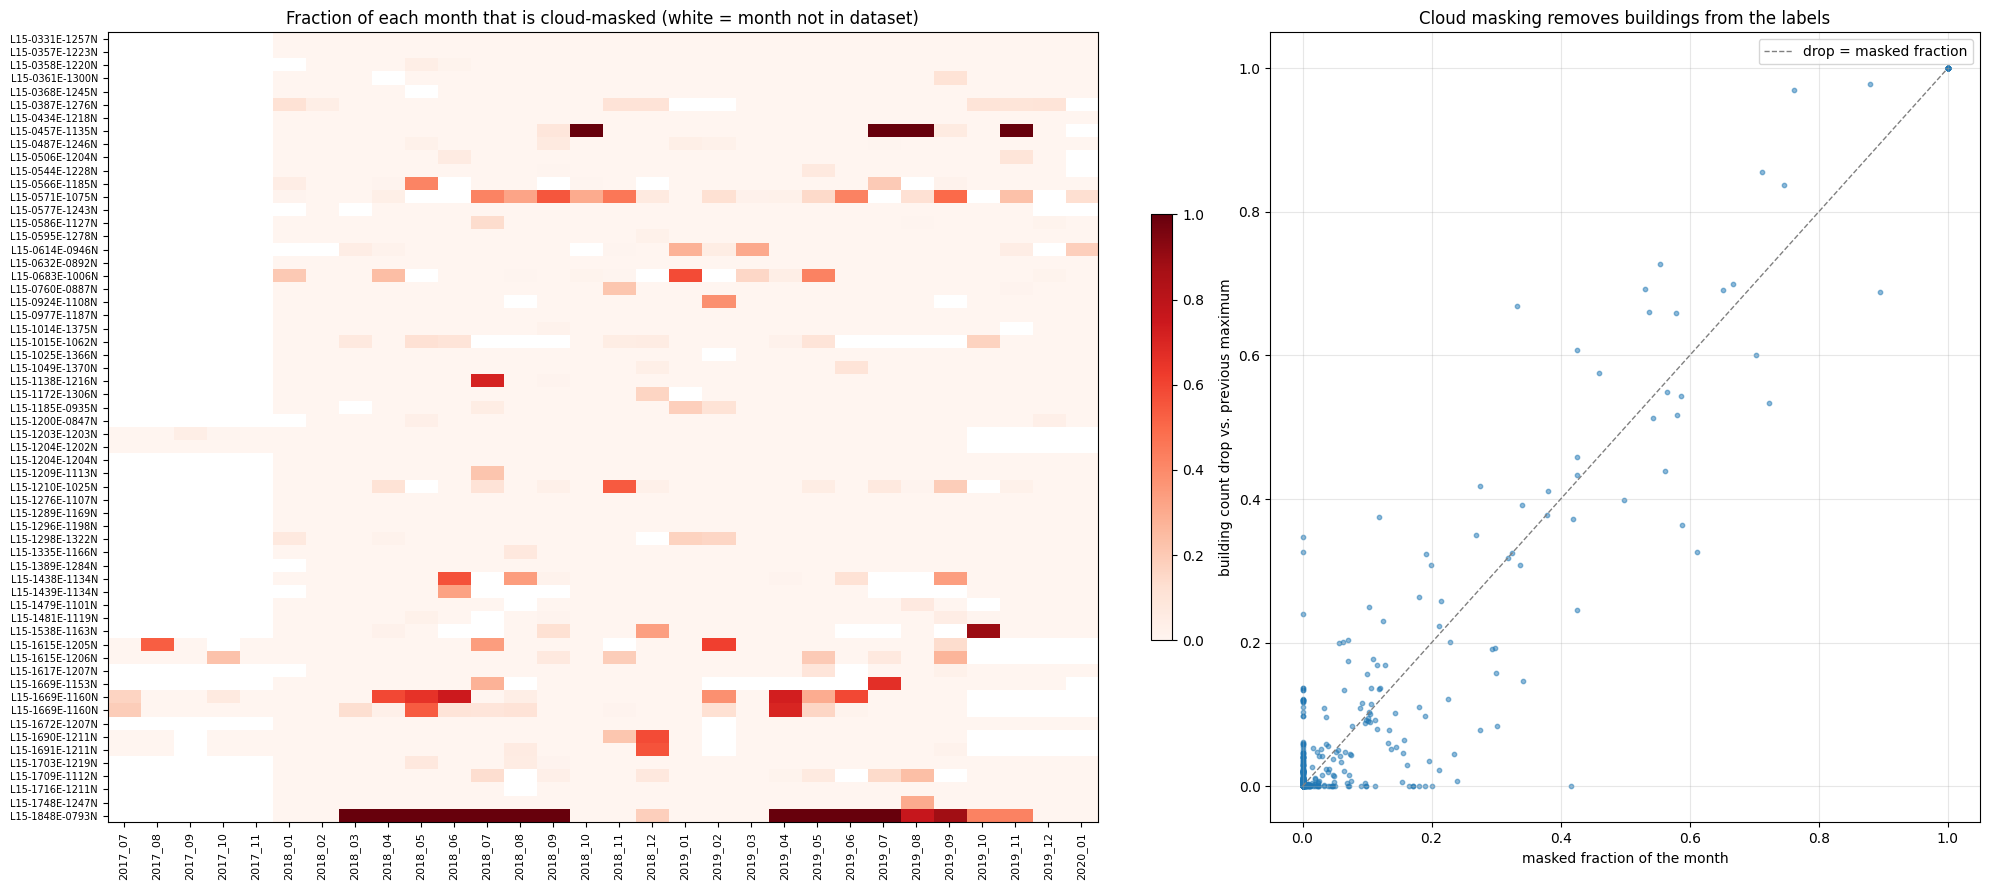

Location-months with any masking: 201 of 1423 | average masked fraction over all months: 3.3%
Correlation between masked fraction and building-count drop: 0.96


In [8]:
def masked_fraction(location, month):
    matches = list((location / "UDM_masks").glob(f"global_monthly_{month}_*.tif"))
    if not matches:
        return 0.0
    with rasterio.open(matches[0]) as src:
        mask = src.read(1, out_shape=(256, 256), resampling=Resampling.average)
    return float((mask > 0).mean())


jobs = [(loc_id, m) for loc_id, d in info.items() for m in d["months"]]
with ThreadPoolExecutor(max_workers=16) as pool:
    fractions = list(tqdm(pool.map(lambda job: masked_fraction(DATA_ROOT / job[0], job[1]), jobs), total=len(jobs), desc="UDM masks"))
masked = pd.DataFrame(np.nan, index=list(info), columns=all_months)
for (loc_id, m), frac in zip(jobs, fractions):
    masked.loc[loc_id, m] = frac

drop = 1 - counts / counts.cummax()

fig, axes = plt.subplots(1, 2, figsize=(20, 9), gridspec_kw={"width_ratios": [3, 2]})
im = axes[0].imshow(masked.values, cmap="Reds", aspect="auto", interpolation="nearest", vmin=0, vmax=1)
axes[0].set_xticks(range(len(all_months)))
axes[0].set_xticklabels(all_months, rotation=90, fontsize=8)
axes[0].set_yticks(range(len(masked)))
axes[0].set_yticklabels([i[:15] for i in masked.index], fontsize=7)
axes[0].set_title("Fraction of each month that is cloud-masked (white = month not in dataset)")
plt.colorbar(im, ax=axes[0], fraction=0.02)

x, y = masked.values.T.flatten(), drop.values.flatten()
ok = ~np.isnan(x) & ~np.isnan(y)
axes[1].scatter(x[ok], y[ok], s=10, alpha=0.5)
axes[1].plot([0, 1], [0, 1], color="grey", linewidth=1, linestyle="--", label="drop = masked fraction")
axes[1].set_xlabel("masked fraction of the month")
axes[1].set_ylabel("building count drop vs. previous maximum")
axes[1].set_title("Cloud masking removes buildings from the labels")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cloud_masks.png", dpi=150)
plt.show()

cloudy = int((masked > 0).sum().sum())
print(f"Location-months with any masking: {cloudy} of {int(masked.notna().sum().sum())} | "
      f"average masked fraction over all months: {100 * np.nanmean(masked.values):.1f}%")
print(f"Correlation between masked fraction and building-count drop: {np.corrcoef(x[ok], y[ok])[0, 1]:.2f}")

## Step 9: Data quality summary

One table per location, saved to `exploration/dataset_summary.csv`: months, image/label mismatches, building counts, growth, the largest single-month drop, cloudy months, and the average masked fraction. The checks below flag locations to be careful with:
- months with **zero buildings** (usually fully clouded)
- **image/label mismatches** (a month with one but not the other)
- locations with **more than 20% average masking**

None of these need to be excluded: Parts 1–4 handle them, but it's worth knowing which locations they are.

In [9]:
summary = inventory_df.join(growth[["growth", "largest_month_drop"]])
summary["avg_masked_fraction"] = masked.mean(axis=1)
summary["zero_building_months"] = (counts == 0).sum()
summary = summary.drop(columns=["has_UDM_folder"]).round(3)
summary.to_csv(OUTPUT_DIR / "dataset_summary.csv")

print(f"Locations with a zero-building month: {(summary['zero_building_months'] > 0).sum()}")
print(f"Locations with image/label mismatches: {(summary['image_label_mismatch'] > 0).sum()}")
print(f"Locations with > 20% average masking: {(summary['avg_masked_fraction'] > 0.2).sum()}")
print(f"\nSaved to {OUTPUT_DIR / 'dataset_summary.csv'}")
summary.sort_values("largest_month_drop", ascending=False).head(10)

Locations with a zero-building month: 2
Locations with image/label mismatches: 0
Locations with > 20% average masking: 1

Saved to /content/drive/MyDrive/datasets/spacenet7_cache/exploration/dataset_summary.csv


,months,first,last,images,image_label_mismatch,buildings_first,buildings_last,unique_ids,cloudy_months (UDM),growth,largest_month_drop,avg_masked_fraction,zero_building_months
location,,,,,,,,,,,,,
L15-0457E-1135N_1831_3648_13,24,2018_01,2019_12,24,0,13469,13962,14034,6,1.037,1.000,0.173,4
L15-1848E-0793N_7394_5018_13,25,2018_01,2020_01,25,0,653,1515,1536,16,2.320,1.000,0.547,11
L15-1138E-1216N_4553_3325_13,25,2018_01,2020_01,25,0,4428,5429,5504,2,1.226,0.855,0.029,0
L15-1669E-1160N_6678_3548_13,26,2017_07,2019_09,26,0,2785,3259,3352,10,1.170,0.837,0.163,0
L15-0571E-1075N_2287_3888_13,20,2018_01,2020_01,20,0,16451,12926,17046,17,0.786,0.727,0.193,0
L15-1669E-1153N_6678_3579_13,18,2018_01,2019_12,18,0,1134,1219,1399,2,1.075,0.700,0.052,0
L15-1615E-1205N_6460_3370_13,24,2017_07,2019_09,24,0,2775,2586,2928,4,0.932,0.693,0.067,0
L15-1538E-1163N_6154_3539_13,20,2018_01,2020_01,20,0,11257,11894,11949,4,1.057,0.688,0.068,0
L15-1669E-1160N_6679_3549_13,26,2017_07,2019_09,26,0,4667,5674,6872,12,1.216,0.660,0.084,0
